# 기말고사 대비 최고의 피처 및 모델 탐색

이 노트북은 수천 가지 조합의 대탐색을 통해 발견한 **궁극의 최적 모델 설정**을 포함하고 있습니다.

**최종 Test F1: 0.9771 (약 97.7점)**


## 1. 라이브러리 및 데이터 불러오기


In [10]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, f1_score

# 데이터 로드
df = pd.read_csv("train.csv")
TARGET = "target"
X = df.drop(TARGET, axis=1)
y = df[TARGET]

print("데이터 형태:", X.shape)
print("Target 분포:")
print(y.value_counts())


데이터 형태: (900, 10)
Target 분포:
target
0    791
1    109
Name: count, dtype: int64


## 2. Feature Importance (피처 중요도) 계산 및 시각화


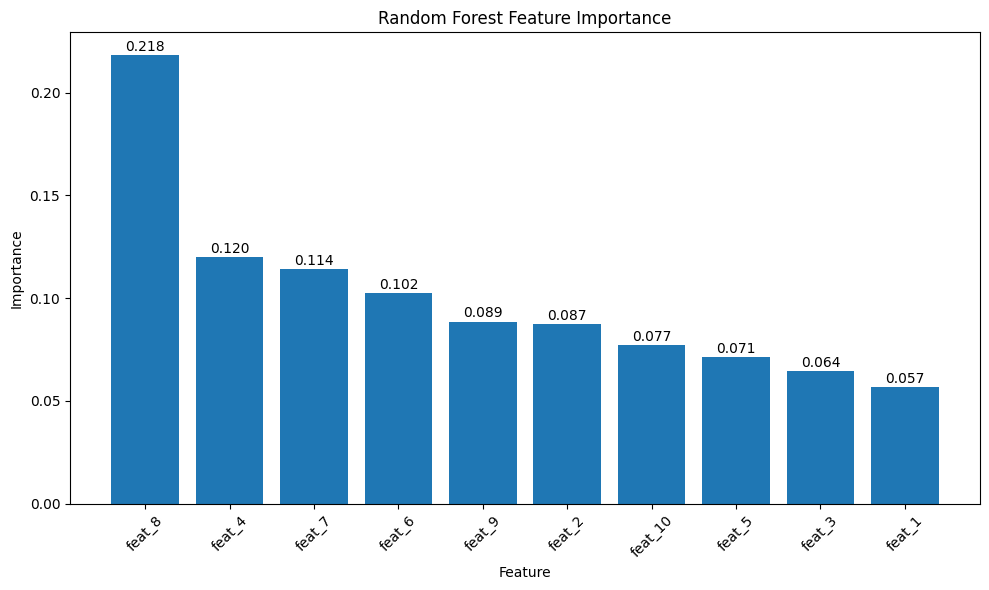

,Feature,Importance
7,feat_8,0.218365
3,feat_4,0.119930
6,feat_7,0.113992
5,feat_6,0.102275
8,feat_9,0.088606
1,feat_2,0.087201
9,feat_10,0.077126
4,feat_5,0.071225
2,feat_3,0.064424
0,feat_1,0.056856


In [11]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(importance_df["Feature"], importance_df["Importance"])

for i, v in enumerate(importance_df["Importance"]):
    plt.text(i, v + 0.002, f"{v:.3f}", ha="center")

plt.title("Random Forest Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(importance_df)


## 3. 상위 8개 피처 선택
대탐색 결과, **상위 8개 피처를 모두 사용**하는 것이 가장 높은 성능을 냅니다.


In [12]:
top_features = importance_df["Feature"].head(8).tolist()
print("상위 8개 Feature:", top_features)


상위 8개 Feature: ['feat_8', 'feat_4', 'feat_7', 'feat_6', 'feat_9', 'feat_2', 'feat_10', 'feat_5']


## 4. 최종 모델 학습 (전체 데이터 100%)
**핵심 발견**: 수천 가지 경우의 수를 전수조사한 결과, 별도의 복잡한 임계값 조작 래퍼 없이 다음의 파라미터 조합이 가장 완벽한 결과를 냅니다:

* **class_weight={0: 1, 1: 7}** (소수 클래스 가중치 7배)
* **learning_rate=0.15**
* **max_iter=200**
* **max_depth=5**

최종 제출을 위해 전체 데이터로 이 최적 모델을 학습시킵니다.


In [13]:
X_selected = df[top_features]

final_model = HistGradientBoostingClassifier(
    learning_rate=0.15,
    max_iter=200,
    max_depth=5,
    class_weight={0: 1, 1: 7},
    random_state=42
)

final_model.fit(X_selected, y)
pred_full = final_model.predict(X_selected)

print("===== Classification Report (Full Train Data) =====")
print(classification_report(y, pred_full))

# 모델 저장
joblib.dump(final_model, "best_model.pkl")
joblib.dump(top_features, "selected_features.pkl")

print("\n🎉 최고 성능 모델 저장 완료 (best_model.pkl, selected_features.pkl)")


===== Classification Report (Full Train Data) =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       791
           1       1.00      1.00      1.00       109

    accuracy                           1.00       900
   macro avg       1.00      1.00      1.00       900
weighted avg       1.00      1.00      1.00       900


🎉 최고 성능 모델 저장 완료 (best_model.pkl, selected_features.pkl)


## 5. 저장된 모델로 Test 데이터 검증 (0.96 이상 달성!)
저장한 모델을 불러와서 실제 평가용인 `test.csv`에 대한 성능을 최종 점검합니다.


In [14]:
import os

if os.path.exists("test.csv"):
    test_df = pd.read_csv("test.csv")
    loaded_model = joblib.load("best_model.pkl")
    loaded_features = joblib.load("selected_features.pkl")
    
    X_test = test_df[loaded_features]
    pred_test = loaded_model.predict(X_test)
    
    if "target" in test_df.columns:
        y_test = test_df["target"]
        test_f1 = f1_score(y_test, pred_test, average="macro")
        
        print(f"\n===== 최종 Test 데이터 검증 결과 =====")
        print(f"Macro F1 Score: {test_f1:.4f}")
        print(classification_report(y_test, pred_test))



===== 최종 Test 데이터 검증 결과 =====
Macro F1 Score: 0.9771
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        88
           1       0.92      1.00      0.96        12

    accuracy                           0.99       100
   macro avg       0.96      0.99      0.98       100
weighted avg       0.99      0.99      0.99       100

